In [1]:
import pandas as pd
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import OrdinalEncoder

from src.helper import get_split_data

In [2]:
# df = pd.read_csv('../../data/preprocessed/preprocessed_1.csv')
X_trn, y_trn, X_val, y_val, X_tst, y_tst = get_split_data.split_data_for_training(3, 'data/preprocessed/preprocessed_1.csv', 17)

In [3]:
print(X_trn.shape)
print(X_val.shape)
print(X_tst.shape)

(1268, 45)
(10, 45)
(10, 45)


In [4]:
var_threshold = VarianceThreshold(threshold=0.05)

In [5]:
clean_data_trn = var_threshold.fit_transform(X_trn)
clean_data_val = var_threshold.transform(X_val)
clean_data_test = var_threshold.transform(X_tst)
print(var_threshold.variances_)
print(clean_data_trn.shape)
print(clean_data_val.shape)
print(clean_data_test.shape)

[3.27408952e+02 3.22610238e+02 8.65798433e-01 1.12678910e+01
 9.81270108e+01 1.04086542e+00 1.00662477e+01 1.03166563e+02
 3.67022967e+01 3.47195546e+01 7.17701806e+01 6.27648894e+01
 6.30160668e+01 1.13191823e+02 2.83414020e+01 2.67667214e+01
 5.49553063e+01 1.56787067e-01 2.22878664e-01 2.20979982e-01
 1.32273916e-01 2.42115288e-02 6.17504308e-02 2.26696623e+00
 9.66120555e-01 2.22206427e-01 1.35945114e-01 2.47657816e-02
 6.70306947e-02 2.27139090e+00 9.48075570e-01 4.34240180e-01
 2.72274438e-01 5.09673296e-02 1.32791198e-01 4.67354040e+00
 1.98125251e+00 1.91834243e+02 1.34648990e-01 6.90468559e-01
 3.02611169e-01 1.85369338e+00 1.63605692e-01 4.02626322e-01
 6.97439653e-01]
(1268, 43)
(10, 43)
(10, 43)


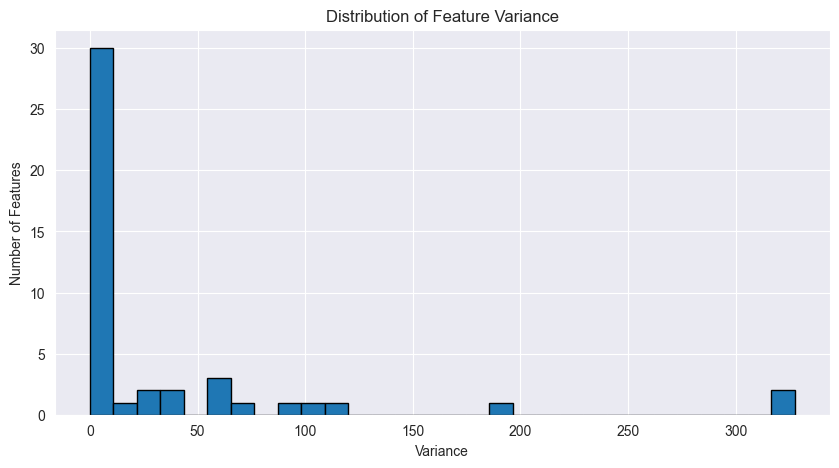

In [6]:
import matplotlib.pyplot as plt

variances = var_threshold.variances_

plt.figure(figsize=(10, 5))
plt.hist(variances, bins=30, edgecolor="black")
plt.xlabel("Variance")
plt.ylabel("Number of Features")
plt.title("Distribution of Feature Variance")
plt.show()

In [11]:
low_variance_threshold = 10
var_threshold = VarianceThreshold(threshold=low_variance_threshold)

var_threshold.fit(X_trn)
selected_features = X_trn.columns[var_threshold.get_support()]

clean_data_trn = pd.DataFrame(var_threshold.transform(X_trn), columns=selected_features)
clean_data_val = pd.DataFrame(var_threshold.transform(X_val), columns=selected_features)
clean_data_test = pd.DataFrame(var_threshold.transform(X_tst), columns=selected_features)

print(f"Remaining features in train: {clean_data_trn.shape[1]}")
print(f"Remaining features in val: {clean_data_val.shape[1]}")
print(f"Remaining features in test: {clean_data_test.shape[1]}")

Remaining features in train: 16
Remaining features in val: 16
Remaining features in test: 16


In [12]:
clean_data_trn

,points_home,points_away,home_last_team_shoton,home_last_team_possession,away_last_team_shoton,away_last_team_possession,team_strength_home,team_strength_away,strength_difference,team_aggression_home,team_aggression_away,aggression_difference,team_acceleration_home,team_acceleration_away,acceleration_difference,points_diff
0,0.0,0.0,9.0,40.0,5.0,52.0,74.781818,67.438889,7.342929,68.927273,64.991053,3.936219,80.709091,81.409812,-0.700722,0.0
1,0.0,0.0,8.0,48.0,2.0,60.0,68.266919,66.648485,1.618434,47.432071,58.785859,-11.353788,77.711616,66.722222,10.989394,0.0
2,0.0,0.0,7.0,54.0,9.0,37.0,71.960354,71.607828,0.352525,65.989899,66.782828,-0.792929,78.963131,76.503535,2.459596,0.0
3,0.0,0.0,11.0,47.0,7.0,54.0,69.084848,52.832071,16.252778,53.248485,57.688384,-4.439899,76.627273,74.005051,2.622222,0.0
4,0.0,0.0,10.0,40.0,9.0,52.0,60.648196,58.133045,2.515152,67.880375,56.750938,11.129437,74.268975,73.469841,0.799134,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1263,19.0,29.0,4.0,41.0,5.0,59.0,70.545455,70.709091,-0.163636,69.054545,72.109091,-3.054545,77.472727,79.127273,-1.654545,-10.0
1264,14.0,29.0,7.0,57.0,9.0,54.0,63.981818,58.636364,5.345455,67.681818,48.190909,19.490909,71.745455,77.863636,-6.118182,-15.0
1265,18.0,25.0,1.0,73.0,11.0,56.0,73.027273,76.100000,-3.072727,75.927273,70.827273,5.100000,71.754545,65.690909,6.063636,-7.0
1266,10.0,23.0,6.0,46.0,9.0,59.0,77.318182,59.590909,17.727273,71.636364,61.663636,9.972727,78.500000,74.463636,4.036364,-13.0
